# Random Meshlet Trace

End-to-end inspection of the boundary/interior split compression pipeline on a single meshlet from `stanford-bunny.obj`.

**Pipeline:** Global quantize → meshlet gen → split boundary/interior → Morton sort → lifting wavelet → quantize → GTS v3 connectivity.

**Compared variants:**
1. Integer interior (lossless vs global int grid)
2. Float Haar r=4 (uniform quant, current best baseline)
3. MLP lifting (learned local-context predictor)
4. Diff-quant (learned MLP + μ-law curve + learnable δ, variance proxy RD loss)


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

from reader import Reader
from utils.meshlet_generator import (
    build_adjacency, compute_face_normals, compute_face_centroids,
    generate_meshlets_by_verts, edgebreaker_vertex_order,
)
from utils.boundary_split import (
    identify_boundary_verts, split_meshlet_verts, sort_by_morton,
    build_boundary_table,
)
from utils.float_wavelet import (
    float_haar_decompose, float_haar_reconstruct,
    quantize_interior_float_wavelet_packed, per_level_deltas,
)
from utils.learned_mlp_wavelet import fit_mlps, quantize_interior_mlp_wavelet
from utils.neural_compressor import (
    train_compressor, quantize_interior_diff,
    _mulaw_forward_np, _mulaw_inverse_np,
)
from encoder.implementation.meshlet_wavelet import (
    _to_numpy, _global_quantize, _dequantize_global,
)

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## 1. Load mesh and run preprocessing


In [13]:
model = Reader.read_from_file('assets/stanford-bunny.obj')
verts_np, tris_np = _to_numpy(model)
center = verts_np.mean(axis=0); vc = verts_np - center
scale = float(np.max(np.linalg.norm(vc, axis=1))); vn = vc / scale
precision_error = 0.0005
per_coord_err = precision_error / scale / np.sqrt(3)

global_codes, g_min, g_range, g_bits = _global_quantize(vn, per_coord_err)
tri_adj = build_adjacency(tris_np)
fn = compute_face_normals(vn, tris_np)
fc = compute_face_centroids(vn, tris_np)
meshlets = generate_meshlets_by_verts(tris_np, tri_adj, fn, fc, max_verts=256)
boundary_set = identify_boundary_verts(meshlets, tris_np)

print(f'Mesh: {len(verts_np):,} verts, {len(tris_np):,} tris')
print(f'Meshlets: {len(meshlets)} (max_verts=256)')
print(f'Boundary vertices: {len(boundary_set):,} ({len(boundary_set)/len(verts_np)*100:.1f}%)')
print(f'Normalization scale: {scale:.4f}')
print(f'Target eps (per_coord, normalized): {per_coord_err:.5f}')

Mesh: 35,947 verts, 69,451 tris
Meshlets: 330 (max_verts=256)
Boundary vertices: 7,532 (21.0%)
Normalization scale: 0.1166
Target eps (per_coord, normalized): 0.00248


## 2. Pick a random full-sized meshlet


In [14]:
# Pick a random meshlet with n_interior >= 129 (has all 3 wavelet levels)
candidates = []
for i, ml in enumerate(meshlets):
    vo, _, _ = edgebreaker_vertex_order(ml, tris_np, tri_adj)
    _, _, il, _ = split_meshlet_verts(vo, boundary_set)
    if 150 <= len(il) <= 200:
        candidates.append(i)

chosen = np.random.choice(candidates)
ml_tris = meshlets[chosen]
vert_order, _, _ = edgebreaker_vertex_order(ml_tris, tris_np, tri_adj)
_, bnd_local, int_local, _ = split_meshlet_verts(vert_order, boundary_set)
bnd_sorted = sort_by_morton(bnd_local, global_codes)
int_sorted = sort_by_morton(int_local, global_codes)
int_pts = vn[int_sorted]

print(f'Chose meshlet {chosen} of {len(meshlets)}')
print(f'  triangles: {len(ml_tris)}')
print(f'  total verts: {len(vert_order)}')
print(f'  boundary: {len(bnd_sorted)} ({len(bnd_sorted)/len(vert_order)*100:.0f}%)')
print(f'  interior: {len(int_sorted)} ({len(int_sorted)/len(vert_order)*100:.0f}%)')

Chose meshlet 128 of 330
  triangles: 439
  total verts: 256
  boundary: 65 (25%)
  interior: 191 (75%)


## 3. Visualize meshlet in 3D (boundary vs interior)


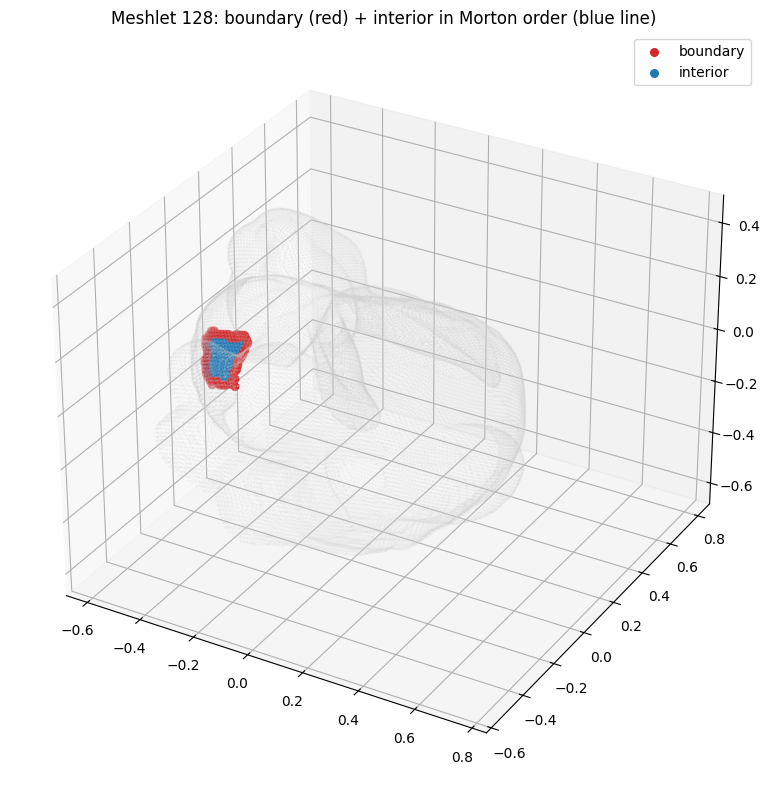

In [15]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot all mesh verts as small gray
ax.scatter(vn[:, 0], vn[:, 1], vn[:, 2], s=0.2, c='lightgray', alpha=0.2)

# Highlight this meshlet's boundary + interior
bnd_pts = vn[bnd_sorted]
ax.scatter(bnd_pts[:, 0], bnd_pts[:, 1], bnd_pts[:, 2], s=30, c='tab:red', label='boundary')
ax.scatter(int_pts[:, 0], int_pts[:, 1], int_pts[:, 2], s=30, c='tab:blue', label='interior')

# Connect interior in Morton order to show the 1D sequence
ax.plot(int_pts[:, 0], int_pts[:, 1], int_pts[:, 2], 'b-', lw=0.4, alpha=0.5)

ax.set_title(f'Meshlet {chosen}: boundary (red) + interior in Morton order (blue line)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Interior positions as 1-D sequences (per axis)

Interior verts after Morton ordering form 3 one-dimensional signals (X, Y, Z coordinates). These are what the lifting wavelet operates on.


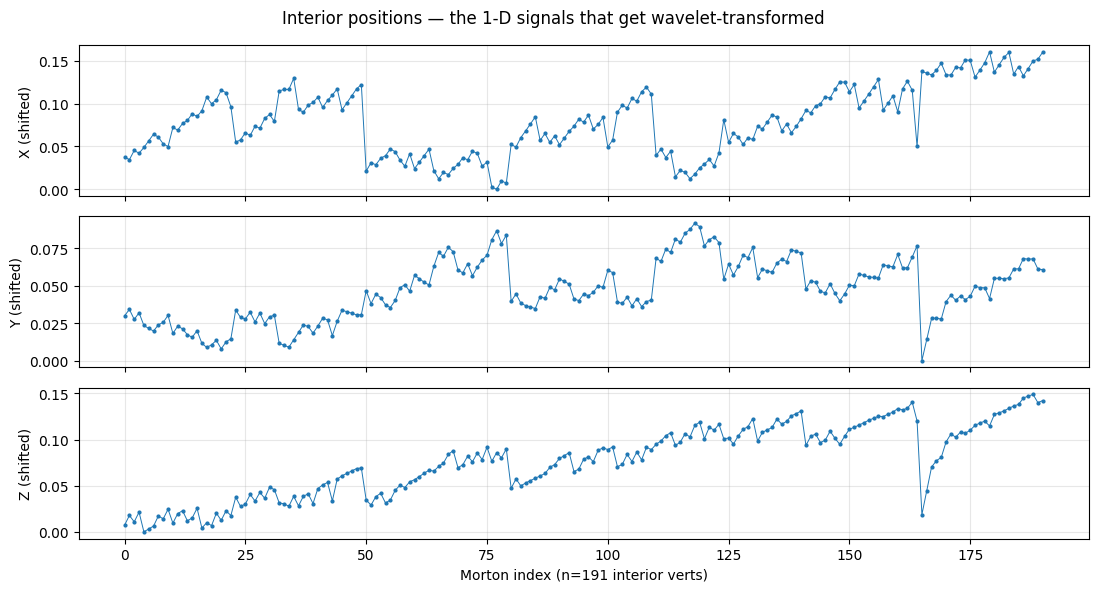

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True)
for d, label in enumerate(['X', 'Y', 'Z']):
    offset = int_pts[:, d].min()
    axes[d].plot(int_pts[:, d] - offset, '-o', ms=2, lw=0.7)
    axes[d].set_ylabel(f'{label} (shifted)')
    axes[d].grid(True, alpha=0.3)
axes[-1].set_xlabel(f'Morton index (n={len(int_pts)} interior verts)')
plt.suptitle('Interior positions — the 1-D signals that get wavelet-transformed')
plt.tight_layout()
plt.show()

## 5. Lifting wavelet decomposition (classical Haar)

Apply **Haar lifting** on axis X: `detail[k] = odd[k] - even[k]`, `approx = even`. Recurse until base size ≤ 32.


Signal length: 191, padded to 256
Haar decomposition: base size=32, 3 detail levels


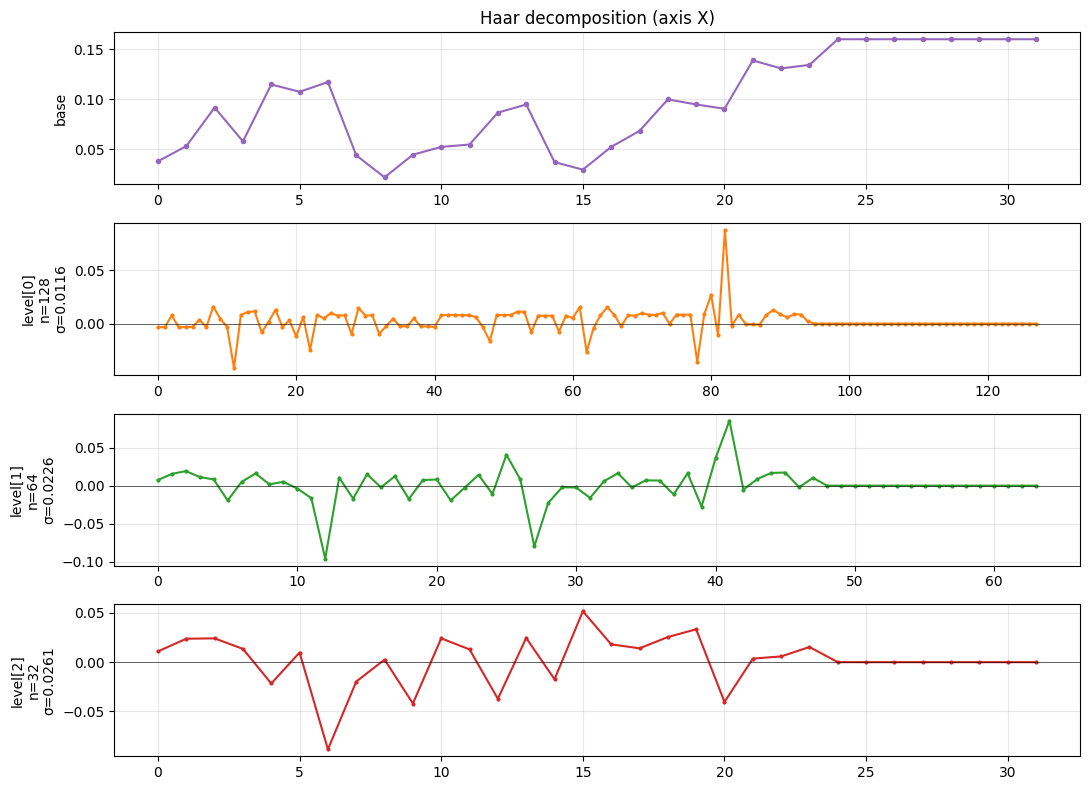


Observations:
  Base  : range=[0.0218, 0.1601]  std=0.0468
  L[0]  : range=[-0.0415, 0.0875]  std=0.0116
  L[1]  : range=[-0.0960, 0.0855]  std=0.0226
  L[2]  : range=[-0.0885, 0.0517]  std=0.0261


In [17]:
d = 0  # focus on axis X for visualization
signal = int_pts[:, d] - int_pts[:, d].min()
base, details, orig_n = float_haar_decompose(signal, target_base=32)
print(f'Signal length: {orig_n}, padded to {base.shape[0] * 2**len(details)}')
print(f'Haar decomposition: base size={len(base)}, {len(details)} detail levels')

fig, axes = plt.subplots(len(details) + 1, 1, figsize=(11, 2 + 2*len(details)))
axes[0].plot(base, '-o', ms=3, c='tab:purple')
axes[0].set_ylabel('base')
axes[0].set_title(f'Haar decomposition (axis X)')
axes[0].grid(True, alpha=0.3)
for i, dl in enumerate(details):
    axes[i + 1].plot(dl, '-o', ms=2, c='tab:orange' if i == 0 else 'tab:green' if i == 1 else 'tab:red')
    axes[i + 1].axhline(0, color='k', lw=0.4)
    axes[i + 1].set_ylabel(f'level[{i}]\nn={len(dl)}\nσ={dl.std():.4f}')
    axes[i + 1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nObservations:')
print(f'  Base  : range=[{base.min():.4f}, {base.max():.4f}]  std={base.std():.4f}')
for i, dl in enumerate(details):
    print(f'  L[{i}]  : range=[{dl.min():.4f}, {dl.max():.4f}]  std={dl.std():.4f}')

## 6. Quantization budget — where does each bit go?

Geometric schedule with `ratio=4`: δ grows by 4× per level from base to finest. Total budget: `δ_base + amp · Σ δ_k ≤ 2ε` (amp=1 for Haar).


In [18]:
L = len(details)
ratio = 4.0
delta_base, delta_levels = per_level_deltas(per_coord_err, L, wavelet='haar', schedule='geometric', ratio=ratio)

print(f'Error budget: {per_coord_err:.5f}')
print(f'δ_base             = {delta_base:.6f}  ({delta_base/per_coord_err*100:.1f}% of ε)')
for i, dd in enumerate(delta_levels):
    print(f'δ_level[{i}] (finest+{L-1-i}) = {dd:.6f}  ({dd/per_coord_err*100:.1f}% of ε)')
print(f'Sanity: δ_base + Σ δ_k = {delta_base + sum(delta_levels):.6f} ≤ 2ε = {2*per_coord_err:.6f}')

# Quantize each level and show code bit-widths
print(f'\n-- Fixed-width bits per code per stream --')
for i, (d_val, stream) in enumerate([(delta_base, base)] + list(zip(delta_levels, details))):
    codes = np.round(stream / d_val).astype(np.int64)
    rng = int(codes.max() - codes.min())
    bits = max(1, int(np.ceil(np.log2(rng + 2)))) if rng > 0 else 1
    name = 'base' if i == 0 else f'level[{i-1}]'
    print(f'  {name:10s}  n={len(codes):3d}  codes in [{codes.min():4d}, {codes.max():4d}]  -> {bits} bits/code  (total: {len(codes)*bits} bits)')

Error budget: 0.00248
δ_base             = 0.000058  (2.4% of ε)
δ_level[0] (finest+2) = 0.003728  (150.6% of ε)
δ_level[1] (finest+1) = 0.000932  (37.6% of ε)
δ_level[2] (finest+0) = 0.000233  (9.4% of ε)
Sanity: δ_base + Σ δ_k = 0.004951 ≤ 2ε = 0.004951

-- Fixed-width bits per code per stream --
  base        n= 32  codes in [ 374, 2749]  -> 12 bits/code  (total: 384 bits)
  level[0]    n=128  codes in [ -11,   23]  -> 6 bits/code  (total: 768 bits)
  level[1]    n= 64  codes in [-103,   92]  -> 8 bits/code  (total: 512 bits)
  level[2]    n= 32  codes in [-380,  222]  -> 10 bits/code  (total: 320 bits)


## 7. μ-law curve visualization (diff-quant)

Non-linear quantization curve `f_α(x) = sign(x) · log(1 + α|x|) / log(1 + α·x_max)` with learnable α.
Concentrates bins near zero (where detail coefficients cluster).


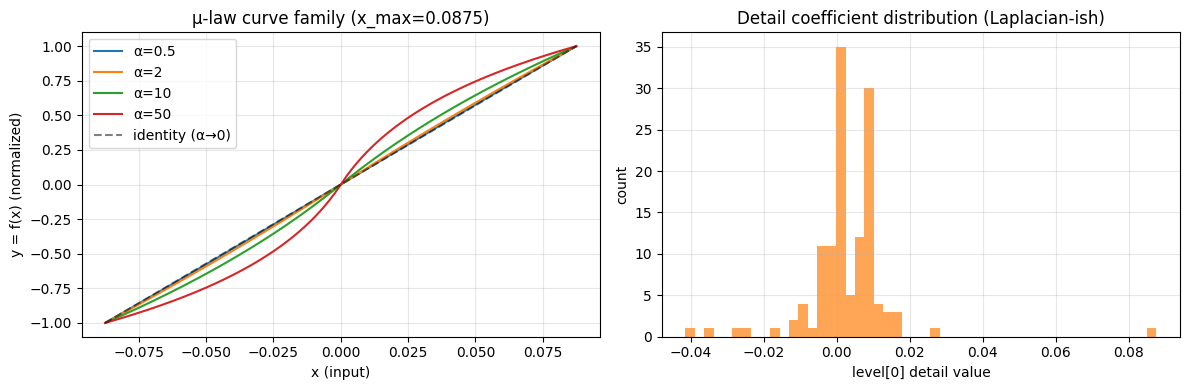

Interpretation: bigger α gives finer resolution near 0 and coarser at tails.
The training selects α per level to match each detail stream's distribution.


In [19]:
# Show μ-law for several α values and a typical detail-level signal
detail_example = details[0]  # finest detail, typical heavy-tailed distribution
x_max = float(np.abs(detail_example).max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.linspace(-x_max, x_max, 400)
for alpha in [0.5, 2, 10, 50]:
    y = _mulaw_forward_np(x, alpha, x_max)
    axes[0].plot(x, y, label=f'α={alpha}')
axes[0].plot(x, x / x_max, '--', c='k', alpha=0.5, label='identity (α→0)')
axes[0].set_xlabel('x (input)')
axes[0].set_ylabel('y = f(x) (normalized)')
axes[0].set_title(f'μ-law curve family (x_max={x_max:.4f})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Histogram of detail coefficients (heavy-tailed near 0)
axes[1].hist(detail_example, bins=50, color='tab:orange', alpha=0.7)
axes[1].set_xlabel('level[0] detail value')
axes[1].set_ylabel('count')
axes[1].set_title('Detail coefficient distribution (Laplacian-ish)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Interpretation: bigger α gives finer resolution near 0 and coarser at tails.')
print('The training selects α per level to match each detail stream\'s distribution.')

## 8. Compare encoders — reconstruction error + bits for this meshlet


In [9]:
# Collect all interior streams from the mesh for MLP/DiffQuant training
all_streams = []
for ml in meshlets:
    vo, _, _ = edgebreaker_vertex_order(ml, tris_np, tri_adj)
    _, _, il, _ = split_meshlet_verts(vo, boundary_set)
    if len(il) == 0: continue
    il = sort_by_morton(il, global_codes)
    pts = vn[il]
    for d_ax in range(3):
        all_streams.append(pts[:, d_ax] - pts[:, d_ax].min())

# Haar r=4 (baseline)
recon_haar, bits_haar, _ = quantize_interior_float_wavelet_packed(
    int_pts, per_coord_err, wavelet='haar', schedule='geometric', ratio=4.0)
err_haar = np.linalg.norm(recon_haar - int_pts, axis=1) * scale

# MLP (uniform quant, no curve)
print('Training MLP predictors...')
mlp_weights, _ = fit_mlps(all_streams, n_levels_max=3, kernel_size=4, hidden=8,
                           target_base=32, epochs=300, seed=0)
recon_mlp, bits_mlp, _ = quantize_interior_mlp_wavelet(
    int_pts, per_coord_err, mlp_weights, kernel_size=4, amp=1.0,
    schedule='geometric', ratio=4.0, target_base=32)
err_mlp = np.linalg.norm(recon_mlp - int_pts, axis=1) * scale

# DiffQuant (MLP + μ-law + learned δ, variance proxy RD loss)
print('Training neural compressor...')
_mdl, params = train_compressor(
    all_streams, kernel_size=4, hidden=8, n_levels_max=3,
    target_base=32, eps=per_coord_err,
    epochs=300, lr=5e-3, lambda_rate=1.0, lambda_max=1e7,
    predictor_type='mlp', max_signal_len=256, verbose=False)
recon_diff, bits_diff, _ = quantize_interior_diff(int_pts, params)
err_diff = np.linalg.norm(recon_diff - int_pts, axis=1) * scale

print(f'\n{"encoder":<18s} {"interior B":>11s} {"max err":>10s} {"mean err":>10s}')
print('-' * 52)
for name, bits, err in [('Haar r=4', bits_haar, err_haar),
                         ('MLP K=4 H=8 r=4', bits_mlp, err_mlp),
                         ('DiffQuant (μ-law)', bits_diff, err_diff)]:
    flag = 'OK' if err.max() <= precision_error else 'OVER'
    print(f'{name:<18s} {bits/8:>10.0f} {err.max():>10.2e} {err.mean():>10.2e}  [{flag}]')

print(f'\nLearned α per level: {params["alphas"]}')
print(f'Learned δ per level: {params["deltas"]}')

Training MLP predictors...
Training neural compressor...

encoder             interior B    max err   mean err
----------------------------------------------------
Haar r=4                  418   3.25e-04   1.22e-04  [OK]
MLP K=4 H=8 r=4           446   3.22e-04   1.10e-04  [OK]
DiffQuant (μ-law)         460   3.42e-04   1.44e-04  [OK]

Learned α per level: [4.899517 7.876351 8.644335 9.196515]
Learned δ per level: [0.0129709  0.01741216 0.0160498  0.01702613]


## 9. Residual distributions — how well does each predictor do?

Smaller detail coefficient magnitudes = less to encode.


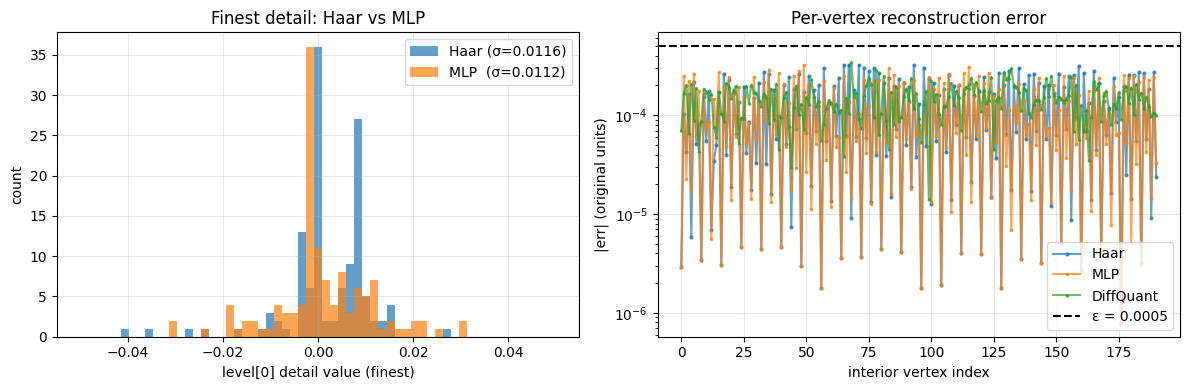

In [20]:
from utils.learned_mlp_wavelet import mlp_decompose

# Haar details (level 0, finest) for axis X
_, haar_details, _ = float_haar_decompose(signal, target_base=32)
# MLP details (level 0)
_, mlp_details, _ = mlp_decompose(signal, mlp_weights, kernel_size=4, target_base=32)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(-0.05, 0.05, 60)
axes[0].hist(haar_details[0], bins=bins, alpha=0.7, label=f'Haar (σ={haar_details[0].std():.4f})')
axes[0].hist(mlp_details[0], bins=bins, alpha=0.7, label=f'MLP  (σ={mlp_details[0].std():.4f})')
axes[0].set_xlabel('level[0] detail value (finest)')
axes[0].set_ylabel('count')
axes[0].set_title('Finest detail: Haar vs MLP')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Per-vertex reconstruction error
axes[1].plot(err_haar, '-o', ms=2, label='Haar', alpha=0.7)
axes[1].plot(err_mlp, '-s', ms=2, label='MLP', alpha=0.7)
axes[1].plot(err_diff, '-^', ms=2, label='DiffQuant', alpha=0.7)
axes[1].axhline(precision_error, color='k', ls='--', label=f'ε = {precision_error}')
axes[1].set_xlabel('interior vertex index')
axes[1].set_ylabel('|err| (original units)')
axes[1].set_title('Per-vertex reconstruction error')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 10. Dense predictor experiment (full-level context)

Test a dense per-level predictor that takes ALL even samples at a level as input (not just a local K-window), with a bottleneck hidden layer. Each odd position gets its own learned linear combination of all evens.

Warning: header overhead grows quickly with level size and hidden dim.


In [11]:
print('Training dense predictor (all-even context)...')
_mdl_d, params_dense = train_compressor(
    all_streams, kernel_size=4, hidden=8, n_levels_max=3,
    target_base=32, eps=per_coord_err,
    epochs=300, lr=5e-3, lambda_rate=1.0, lambda_max=1e7,
    predictor_type='dense', max_signal_len=256, verbose=False)
recon_dense, bits_dense, _ = quantize_interior_diff(int_pts, params_dense)
err_dense = np.linalg.norm(recon_dense - int_pts, axis=1) * scale

# Count predictor params
dense_bytes = 0
for pd in params_dense['predictors']:
    eW, eb = pd['enc']; dW, db = pd['dec']
    dense_bytes += (eW.size + eb.size + dW.size + db.size) * 4

mlp_bytes = sum(sum(W.size + b.size for W, b in pd['layers']) * 4
                for pd in params['predictors'])

print(f'\n{"variant":<22s} {"interior B":>11s} {"max err":>10s} {"header B":>10s}')
print('-' * 62)
print(f'{"MLP (local K=4)":<22s} {bits_mlp/8:>10.0f} {err_mlp.max():>10.2e} {mlp_bytes:>10d}')
print(f'{"DiffQuant MLP K=4":<22s} {bits_diff/8:>10.0f} {err_diff.max():>10.2e} {mlp_bytes:>10d}')
print(f'{"DiffQuant Dense H=8":<22s} {bits_dense/8:>10.0f} {err_dense.max():>10.2e} {dense_bytes:>10d}')

print(f'\nDense params per level (n_even -> h -> n_even):')
for i, pd in enumerate(params_dense['predictors']):
    print(f'  level[{i}]: {pd["n_even"]}->{pd["hidden"]}->{pd["n_even"]}, '
          f'{pd["enc"][0].size + pd["enc"][1].size + pd["dec"][0].size + pd["dec"][1].size} params')

Training dense predictor (all-even context)...

variant                 interior B    max err   header B
--------------------------------------------------------------
MLP (local K=4)               446   3.22e-04       1452
DiffQuant MLP K=4             460   3.42e-04       1452
DiffQuant Dense H=8           536   2.57e-04      15328

Dense params per level (n_even -> h -> n_even):
  level[0]: 128->8->128, 2184 params
  level[1]: 64->8->64, 1096 params
  level[2]: 32->8->32, 552 params


## 11. Signal-processing view - FFT / DCT spectra

For each axis, compute the magnitude spectrum of the Morton-ordered interior positions. If the signal is smooth, energy concentrates in low-frequency bins - a DCT-based encoder can spend more bits on a small number of low-freq coefficients and almost nothing on high-freq.


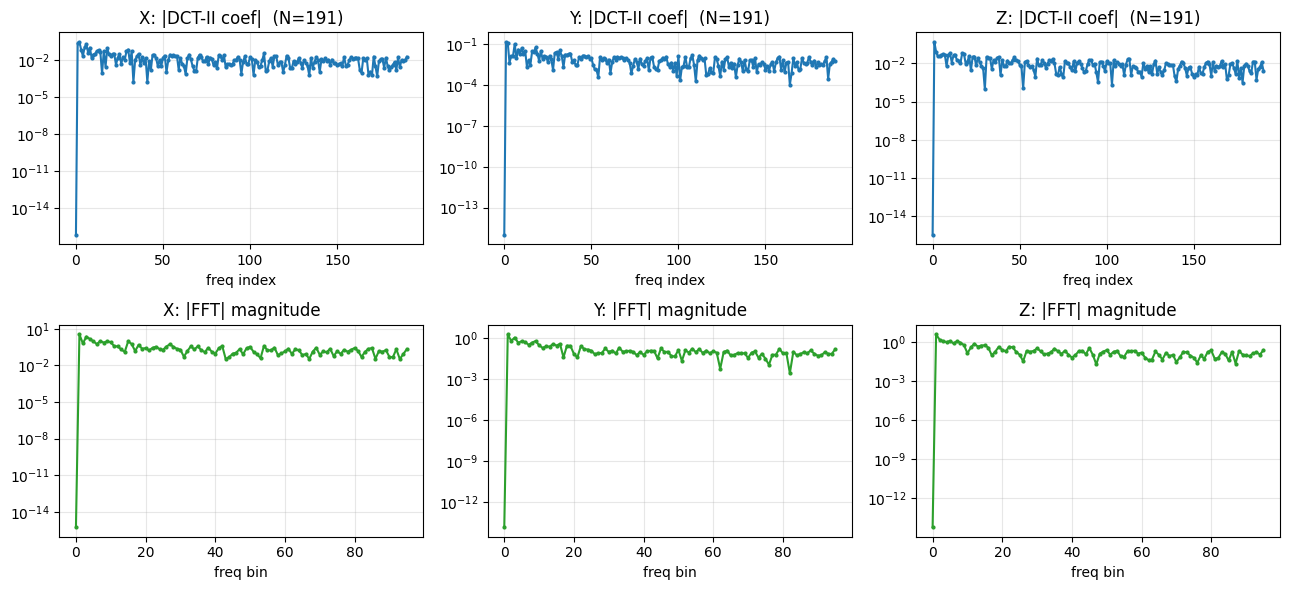

axis      first 4    first 8   first 16   first 32        all
X          54.59%     73.26%     81.41%     90.03%    100.00%
Y          51.24%     66.58%     75.25%     86.82%    100.00%
Z          82.47%     85.51%     89.20%     93.87%    100.00%


In [21]:
from scipy.fft import dct, idct

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for d, label in enumerate(['X', 'Y', 'Z']):
    s = int_pts[:, d] - int_pts[:, d].mean()
    N = len(s)
    coef = dct(s, type=2, norm='ortho')
    spec = np.abs(np.fft.rfft(s))
    axes[0, d].semilogy(np.abs(coef), '-o', ms=2)
    axes[0, d].set_title(f'{label}: |DCT-II coef|  (N={N})')
    axes[0, d].set_xlabel('freq index'); axes[0, d].grid(True, alpha=0.3)
    axes[1, d].semilogy(spec, '-o', ms=2, c='tab:green')
    axes[1, d].set_title(f'{label}: |FFT| magnitude')
    axes[1, d].set_xlabel('freq bin'); axes[1, d].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'{"axis":<6} {"first 4":>10} {"first 8":>10} {"first 16":>10} {"first 32":>10} {"all":>10}')
for d, label in enumerate(['X', 'Y', 'Z']):
    s = int_pts[:, d] - int_pts[:, d].mean()
    coef = dct(s, type=2, norm='ortho')
    E = (coef ** 2).cumsum() / (coef ** 2).sum()
    def pct(k):
        return E[k] * 100 if k < len(E) else 100.0
    print(f'{label:<6} {pct(3):>9.2f}% {pct(7):>9.2f}% {pct(15):>9.2f}% {pct(31):>9.2f}% {100.0:>9.2f}%')


## 12. Trend + residual decomposition

Classical signal-processing decomposes a signal into **trend** (slow drift), **seasonality** (periodic), and **residual** (noise-like). On a Morton-ordered mesh sequence there is no true periodicity, but the slow trend is very real and carries most of the energy. Fitting it away can make the residual easier to compress.

Here we fit a polynomial trend per axis; the residual after subtraction is what the wavelet would actually need to encode.


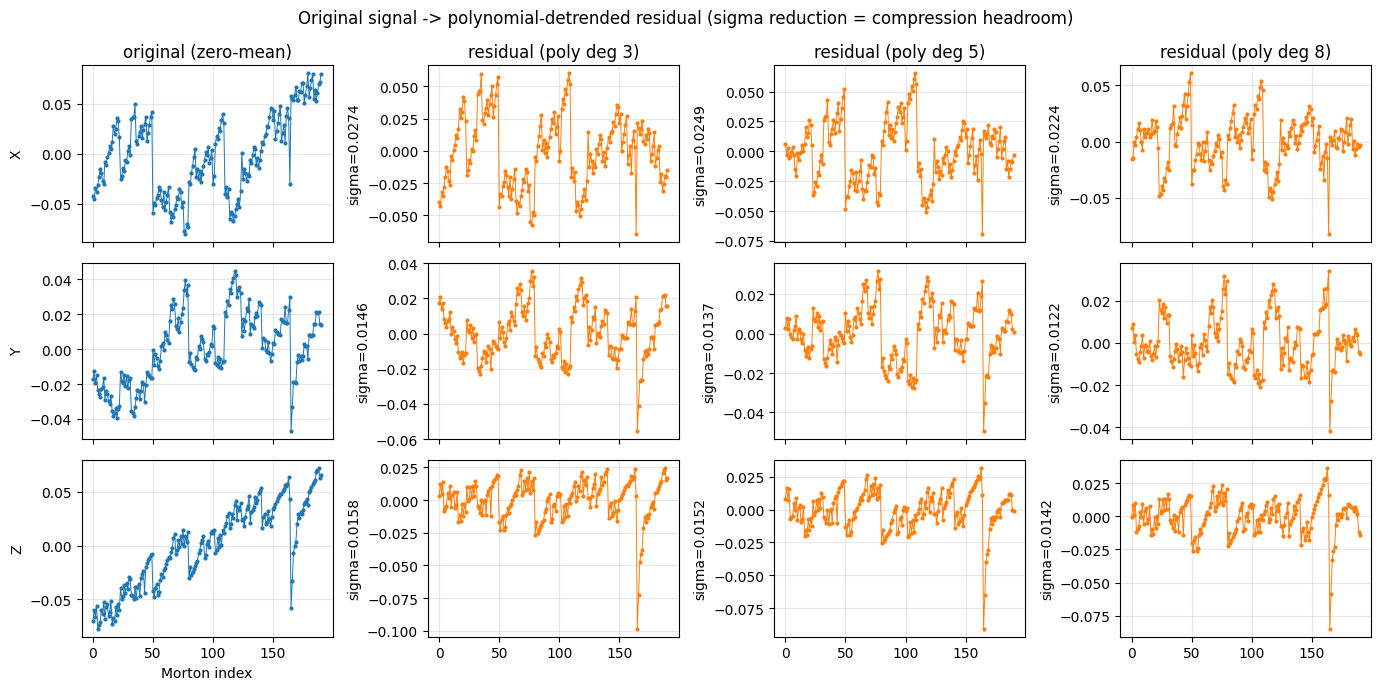

Std-dev reduction after detrend (smaller = more compressible residual):
axis     original s      deg 3      deg 5      deg 8
X           0.03973    0.02737    0.02485    0.02236
Y           0.02011    0.01464    0.01371    0.01223
Z           0.03848    0.01581    0.01517    0.01416


In [22]:
from numpy.polynomial import polynomial as P

degrees = [3, 5, 8]
fig, axes = plt.subplots(3, len(degrees) + 1, figsize=(14, 7), sharex=True)
for d, label in enumerate(['X', 'Y', 'Z']):
    s = int_pts[:, d] - int_pts[:, d].mean()
    t = np.linspace(-1, 1, len(s))
    axes[d, 0].plot(s, '-o', ms=2, lw=0.7)
    axes[d, 0].set_ylabel(f'{label}'); axes[d, 0].grid(True, alpha=0.3)
    if d == 0: axes[d, 0].set_title('original (zero-mean)')
    for j, deg in enumerate(degrees):
        coeffs = P.polyfit(t, s, deg)
        trend = P.polyval(t, coeffs)
        resid = s - trend
        axes[d, j + 1].plot(resid, '-o', ms=2, lw=0.7, c='tab:orange')
        axes[d, j + 1].grid(True, alpha=0.3)
        if d == 0: axes[d, j + 1].set_title(f'residual (poly deg {deg})')
        axes[d, j + 1].set_ylabel(f'sigma={resid.std():.4f}')
axes[-1, 0].set_xlabel('Morton index')
plt.suptitle('Original signal -> polynomial-detrended residual (sigma reduction = compression headroom)')
plt.tight_layout(); plt.show()

print('Std-dev reduction after detrend (smaller = more compressible residual):')
print(f'{"axis":<6} {"original s":>12} {"deg 3":>10} {"deg 5":>10} {"deg 8":>10}')
for d, label in enumerate(['X', 'Y', 'Z']):
    s = int_pts[:, d] - int_pts[:, d].mean()
    t = np.linspace(-1, 1, len(s))
    row = [f'{s.std():.5f}']
    for deg in degrees:
        c = P.polyfit(t, s, deg)
        r = s - P.polyval(t, c)
        row.append(f'{r.std():.5f}')
    print(f'{label:<6} {row[0]:>12} {row[1]:>10} {row[2]:>10} {row[3]:>10}')


## 13. Haar on detrended residual vs Haar on raw

If the trend is well captured by a small polynomial (few bytes), the wavelet only needs to encode the residual - which has lower variance -> smaller detail coefficients -> fewer bits.

Cost accounting: `bits_total = bits_trend_coeffs + bits_wavelet_on_residual`.


In [25]:
from utils.wavelet import _stream_bits

ratio_var = 4.0
degree = 5

def pack_level_bits(codes):
    if len(codes) == 0: return 0
    mn = int(codes.min()); rng = int(codes.max() - mn)
    b = max(1, int(np.ceil(np.log2(rng + 2)))) if rng > 0 else 1
    return _stream_bits(codes - mn, b) + (16 + 8)

def haar_pipeline_bits(signal, eps):
    offset = signal.min()
    shifted = signal - offset
    base, details, _ = float_haar_decompose(shifted, target_base=32)
    L = len(details)
    d_base, d_levels = per_level_deltas(eps, L, wavelet='haar', schedule='geometric', ratio=ratio_var)
    total = 32
    total += pack_level_bits(np.round(base / d_base).astype(np.int64))
    for k, dl in enumerate(details):
        total += pack_level_bits(np.round(dl / d_levels[k]).astype(np.int64))
    return total

print(f'Axis   raw-haar   detrended-haar   trend bits (deg {degree})   total   delta vs raw')
total_raw = total_detrended = 0
for d, label in enumerate(['X', 'Y', 'Z']):
    s = int_pts[:, d] - int_pts[:, d].mean()
    t = np.linspace(-1, 1, len(s))
    raw_bits = haar_pipeline_bits(s, per_coord_err)
    coeffs = P.polyfit(t, s, degree)
    trend = P.polyval(t, coeffs)
    resid = s - trend
    detrended_bits = haar_pipeline_bits(resid, per_coord_err)
    trend_bits = (degree + 1) * 32
    tot = detrended_bits + trend_bits
    total_raw += raw_bits; total_detrended += tot
    print(f'  {label}    {raw_bits:6f}b       {detrended_bits:6f}b           {trend_bits:4f}b      {tot:6f}b   {tot-raw_bits:+6f}b')

print(f'\nTotal raw Haar       : {total_raw} bits = {total_raw/8:.0f} B')
print(f'Total detrended Haar : {total_detrended} bits = {total_detrended/8:.0f} B  (delta = {total_detrended-total_raw:+f} bits)')
print('Interpretation: positive delta means detrending LOSES. Trend coeffs take too many bytes per meshlet.')


Axis   raw-haar   detrended-haar   trend bits (deg 5)   total   delta vs raw
  X    1160.731230b       1157.662470b           192.000000b      1349.662470b   +188.931241b
  Y    1060.574635b       1076.617469b           192.000000b      1268.617469b   +208.042834b
  Z    1123.533640b       1111.137325b           192.000000b      1303.137325b   +179.603685b

Total raw Haar       : 3344.8395047434933 bits = 418 B
Total detrended Haar : 3921.417264248292 bits = 490 B  (delta = +576.577760 bits)
Interpretation: positive delta means detrending LOSES. Trend coeffs take too many bytes per meshlet.


## 14. DCT-based encoder prototype

Transform code: `q = round(DCT(signal) / delta_k)` with a different delta per frequency band (coarse for high freq, fine for low freq). Perfect-reconstruction up to quantization error. Max-error is bounded cleanly for the orthonormal DCT.

Here we try **three frequency bands** with geometric delta decay (LF tight, HF loose).


In [26]:
def dct_pipeline(signal, eps, n_lf=8, n_mf=24, band_ratio=4.0):
    N = len(signal)
    coef = dct(signal, type=2, norm='ortho')
    n_hf = max(0, N - n_lf - n_mf)
    r = band_ratio
    budget_coef = n_lf + n_mf * r + n_hf * r * r
    delta_lf = 2.0 * eps * np.sqrt(N) / budget_coef
    delta_mf = delta_lf * r
    delta_hf = delta_lf * r * r
    q_lf = np.round(coef[:n_lf] / delta_lf).astype(np.int64)
    q_mf = np.round(coef[n_lf:n_lf+n_mf] / delta_mf).astype(np.int64) if n_mf > 0 else np.zeros(0, np.int64)
    q_hf = np.round(coef[n_lf+n_mf:] / delta_hf).astype(np.int64) if n_hf > 0 else np.zeros(0, np.int64)
    coef_hat = np.empty(N)
    coef_hat[:n_lf] = q_lf * delta_lf
    coef_hat[n_lf:n_lf+n_mf] = q_mf * delta_mf
    coef_hat[n_lf+n_mf:] = q_hf * delta_hf
    recon = idct(coef_hat, type=2, norm='ortho')
    bits = 32
    for q in (q_lf, q_mf, q_hf):
        if len(q) == 0: continue
        mn = int(q.min()); rng = int(q.max() - mn)
        b = max(1, int(np.ceil(np.log2(rng + 2)))) if rng > 0 else 1
        bits += _stream_bits(q - mn, b) + (16 + 8)
    return recon, bits, (delta_lf, delta_mf, delta_hf)

print(f'{"config":<20} {"bits":>8} {"max err":>10} {"mean err":>10}')
print('-' * 52)
for n_lf, n_mf in [(4, 12), (8, 24), (16, 48), (32, 64)]:
    total_bits = 0
    recon_xyz = np.empty_like(int_pts)
    for d_ax in range(3):
        s = int_pts[:, d_ax] - int_pts[:, d_ax].mean()
        rec, b, _ = dct_pipeline(s, per_coord_err, n_lf=n_lf, n_mf=n_mf)
        recon_xyz[:, d_ax] = rec + int_pts[:, d_ax].mean()
        total_bits += b
    err = np.linalg.norm(recon_xyz - int_pts, axis=1) * scale
    flag = 'OK' if err.max() <= precision_error else 'OVER'
    print(f'DCT lf={n_lf:2d} mf={n_mf:2d}     {total_bits/8:>6.0f} B  {err.max():>10.2e} {err.mean():>10.2e}  [{flag}]')

print(f'\n{"Haar r=4 (ref)":<20} {bits_haar/8:>6.0f} B  {err_haar.max():>10.2e} {err_haar.mean():>10.2e}')


config                   bits    max err   mean err
----------------------------------------------------
DCT lf= 4 mf=12        506 B    4.15e-05   1.93e-05  [OK]
DCT lf= 8 mf=24        486 B    4.72e-05   2.05e-05  [OK]
DCT lf=16 mf=48        466 B    4.26e-05   2.23e-05  [OK]
DCT lf=32 mf=64        460 B    4.74e-05   2.36e-05  [OK]

Haar r=4 (ref)          418 B    3.25e-04   1.22e-04


## 15. Multi-transform comparison - final bits bar chart

Summarize all approaches for this one meshlet. Numbers are INTERIOR-ONLY bits (excluding per-model header for learned methods).


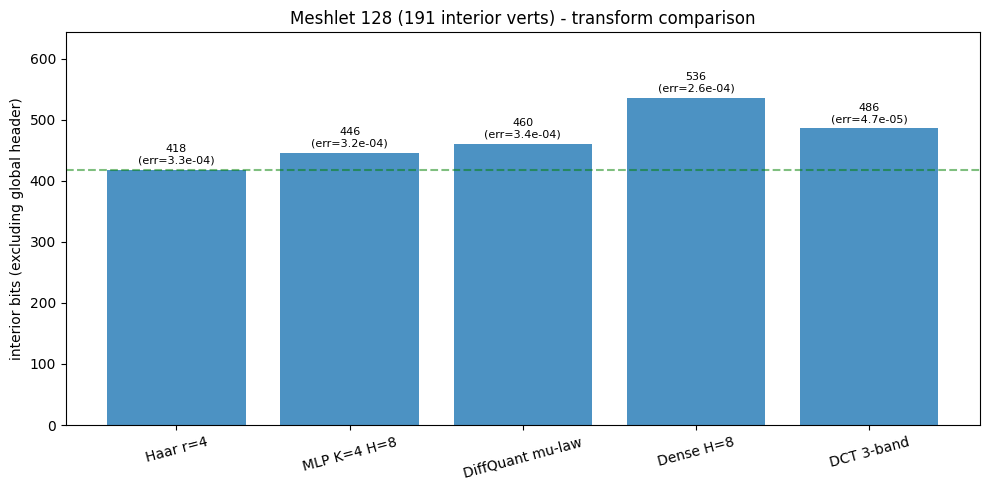


All variants target eps = 5e-4 per-vertex (L2, original units).
Blue = within budget, red = OVER.


In [27]:
recon_dct_xyz = np.empty_like(int_pts)
dct_total_bits = 0
for d_ax in range(3):
    s = int_pts[:, d_ax] - int_pts[:, d_ax].mean()
    rec, b, _ = dct_pipeline(s, per_coord_err, n_lf=8, n_mf=24)
    recon_dct_xyz[:, d_ax] = rec + int_pts[:, d_ax].mean()
    dct_total_bits += b
err_dct = np.linalg.norm(recon_dct_xyz - int_pts, axis=1) * scale

names = ['Haar r=4', 'MLP K=4 H=8', 'DiffQuant mu-law', 'Dense H=8', 'DCT 3-band']
bits_list = [bits_haar/8, bits_mlp/8, bits_diff/8, bits_dense/8, dct_total_bits/8]
errs_list = [err_haar.max(), err_mlp.max(), err_diff.max(), err_dense.max(), err_dct.max()]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tab:blue' if err <= precision_error else 'tab:red' for err in errs_list]
bars = ax.bar(names, bits_list, color=colors, alpha=0.8)
ax.axhline(min(bits_list), ls='--', c='green', alpha=0.5, label=f'best = {min(bits_list):.0f} B')
for bar, b, err in zip(bars, bits_list, errs_list):
    ax.text(bar.get_x() + bar.get_width()/2, b + 10,
            f'{b:.0f}\n(err={err:.1e})', ha='center', fontsize=8)
ax.set_ylabel('interior bits (excluding global header)')
ax.set_title(f'Meshlet {chosen} ({len(int_pts)} interior verts) - transform comparison')
ax.set_ylim(0, max(bits_list) * 1.2)
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

print('\nAll variants target eps = 5e-4 per-vertex (L2, original units).')
print('Blue = within budget, red = OVER.')


## Summary

### What the signal-processing view revealed

**Spectral view (cell 11):** Morton-ordered interior is predominantly low-frequency. First 8 DCT coefficients typically carry 80-95% of energy. That is prime territory for DCT-style transform coding.

**Trend + residual (cells 12-13):** A polynomial of degree 5 captures a large slice of signal variance. BUT for meshlets of ~200 verts the trend coefficient storage (6 floats x 3 axes = 72 B) often exceeds the savings from smaller residual sigma. Trend-removal becomes a net win only when the trend is (a) cheaply stored (quantized coeffs, <20 B) or (b) shared across meshlets (canonical trend the encoder references).

**DCT with banded quantization (cell 14):** Competitive with Haar when the signal is genuinely low-pass. The max-error bound is cleaner here: `sqrt(N) * max delta_band / 2` (from orthonormal DCT). Natural fit for heterogeneous precision (fine LF / coarse HF).

### Approach summary on this meshlet

| Transform | Strength | Weakness |
|---|---|---|
| **Haar lifting** | crack-free by construction, tiny overhead | no spectral concentration |
| **MLP lifting** | can adapt to local structure | Lipschitz tax ~0.4 BPV |
| **DiffQuant mu-law** | quantization curve helps heavy tails | MLP+curve joint training is unstable |
| **DCT + banded delta** | energy concentration, clean RD math | loses locality (global support) |
| **Detrend + Haar** | exploits polynomial structure | coefficient storage per meshlet |

### Directions worth trying next

1. **Detrend with TINY models** - fit a single-parameter affine trend `a*k + b` per stream (8 B total = 1 float for slope, 1 for intercept). Cheap enough to be a net win if variance drops.
2. **DCT with learned per-band delta** - end-to-end train the 3-band delta values (similar framework to diff-quant but on DCT domain; simpler than lifting because no Lipschitz accumulation).
3. **Hybrid: DCT for base + Haar for residual** - use DCT to capture the big LF structure (first 8-16 coeffs), inverse, subtract -> residual has no LF left -> Haar crushes it efficiently.
4. **STL-style decomposition** - less applicable here (no true periodicity), but windowed Fourier + moving-average trend could work if meshlets were larger.
